In [1]:
# from google.colab import drive
# drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# BASE_DIR = "/content/drive/MyDrive/Colab Notebooks/"
BASE_DIR = ""

In [3]:
import re
import math
import string
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
)
from sklearn.calibration import calibration_curve


In [4]:
RANDOM_STATE = 42
JOBS = -1

In [5]:
def _safe_hist(ax, data, bins=50, title="", xlabel="", ylabel="Count", logy=False):
    data = np.asarray(data)
    data = data[~np.isnan(data)]
    if data.size == 0:
        ax.text(0.5, 0.5, "No data", ha="center", va="center")
        return
    ax.hist(data, bins=bins, edgecolor="black", linewidth=0.5)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if logy:
        ax.set_yscale("log")
    ax.grid(True, linestyle=":", alpha=0.6)


def _bar(ax, labels, values, title="", xlabel="", ylabel="Count"):
    ax.bar(labels, values)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(True, axis="y", linestyle=":", alpha=0.6)
    for i, v in enumerate(values):
        ax.text(i, v, f"{v}", ha="center", va="bottom", fontsize=8)


def _print_section(title: str):
    print("\n" + "=" * 80)
    print(title)
    print("=" * 80)

In [6]:
# ---------------------------
# 1) Load data
# ---------------------------
warnings.filterwarnings("ignore")

TRAIN_PATH = BASE_DIR + "train.csv"
VAL_PATH   = BASE_DIR + "val.csv"
TEST_PATH  = BASE_DIR + "test.csv"

train = pd.read_csv(TRAIN_PATH)
val   = pd.read_csv(VAL_PATH)
test  = pd.read_csv(TEST_PATH)

assert {'id','text','label'}.issubset(train.columns)
assert {'id','text','label'}.issubset(val.columns)
assert {'id','text'}.issubset(test.columns)

# Standardize types
train['label'] = train['label'].astype(int)
val['label'] = val['label'].astype(int)


Basic shape & schema
Train shape: (319071, 3)
Val shape: (56792, 3)
Test shape: (60743, 2)

Column dtypes (train):
 text     object
label     int64
id        int64
dtype: object

Missingness & empties
train: missing rates ->
text     0.0
label    0.0
id       0.0
dtype: float64
train: empty 'text' proportion -> 0.0
val: missing rates ->
text     0.0
label    0.0
id       0.0
dtype: float64
val: empty 'text' proportion -> 0.0
test: missing rates ->
id      0.0
text    0.0
dtype: float64
test: empty 'text' proportion -> 0.0

Duplicate checks
train: duplicate id=0, duplicate text=0
val: duplicate id=0, duplicate text=0
test: duplicate id=0, duplicate text=762

Label distribution (train vs val)
Train label distribution (prop):
 label
0    0.708
1    0.292
Name: count, dtype: float64
Val label distribution (prop):
 label
0    0.493
1    0.507
Name: count, dtype: float64


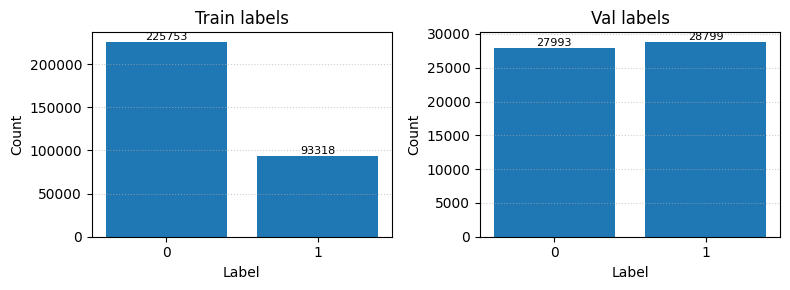


Text length statistics
train char lengths:
count    319071.00
mean       1228.02
std        1421.56
min          21.00
50%         675.00
90%        3448.00
95%        4394.00
99%        5866.00
max       59509.00
Name: text, dtype: float64

val char lengths:
count    56792.00
mean      1240.14
std       1489.14
min         23.00
50%        681.00
90%       3384.00
95%       4399.00
99%       6235.09
max      36178.00
Name: text, dtype: float64

test char lengths:
count    60743.00
mean      1244.83
std       1435.97
min         24.00
50%        727.00
90%       3201.00
95%       4301.00
99%       6121.58
max      63723.00
Name: text, dtype: float64



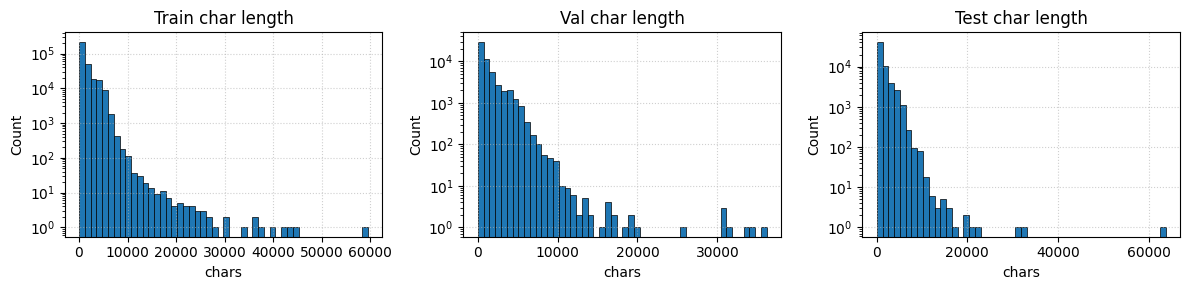


Token statistics (simple whitespace)
train token lengths:
count    319071.00
mean        211.46
std         243.16
min           6.00
50%         115.00
90%         606.00
95%         783.00
99%         907.00
max       10090.00
Name: text, dtype: float64

val token lengths:
count    56792.00
mean       214.06
std        258.65
min          6.00
50%        115.00
90%        592.00
95%        785.00
99%       1032.09
max       6243.00
Name: text, dtype: float64

test token lengths:
count    60743.00
mean       214.20
std        248.28
min          6.00
50%        122.00
90%        555.00
95%        769.00
99%        998.00
max      10129.00
Name: text, dtype: float64



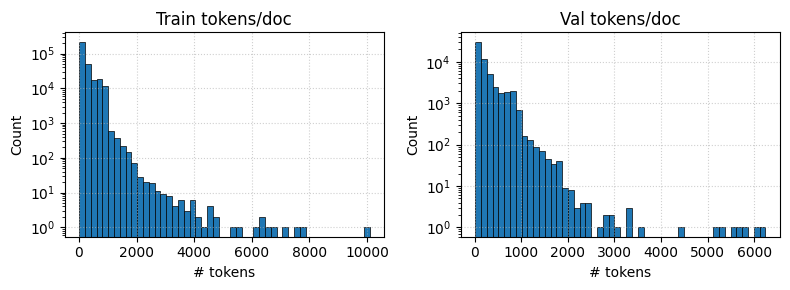


Leakage check: exact text overlap
train∩val texts: 0
train∩test texts: 0
val∩test texts: 52

Top n-grams by class (CountVectorizer, memory-capped)
Top n-grams leaning to label=1:
to hear (log-ratio=7.34)
cut off (log-ratio=7.34)
to save (log-ratio=7.34)
was fun (log-ratio=7.34)
selling (log-ratio=7.34)
2020 (log-ratio=7.34)
item (log-ratio=7.34)
find something (log-ratio=7.34)
magic (log-ratio=7.34)
upwards (log-ratio=7.34)
memorial (log-ratio=7.34)
applications such (log-ratio=7.33)
eyes were (log-ratio=7.33)
yesterday (log-ratio=7.33)
hackers (log-ratio=7.26)
michelle (log-ratio=6.65)
us happy (log-ratio=6.64)
speed and (log-ratio=6.24)
come back (log-ratio=6.24)
who might (log-ratio=6.24)

Top n-grams leaning to label=0:
bigger (log-ratio=-6.33)
of california (log-ratio=-4.58)
mini (log-ratio=-4.46)
rational (log-ratio=-4.40)
hear (log-ratio=-4.05)
his office (log-ratio=-4.03)
long before (log-ratio=-4.00)
revolution (log-ratio=-3.90)
matter of (log-ratio=-3.88)
edward (log-ratio=-

In [7]:
# ---------------------------
# 2) EXPLORATORY DATA ANALYSIS
# ---------------------------
_print_section("Basic shape & schema")
print("Train shape:", train.shape)
print("Val shape:", val.shape)
print("Test shape:", test.shape)
print("\nColumn dtypes (train):\n", train.dtypes)

_print_section("Missingness & empties")
for name, df in [("train", train), ("val", val), ("test", test)]:
    miss = df.isnull().mean().round(4)
    empty_text = (df['text'].fillna("").str.strip().eq("")).mean().round(4)
    print(f"{name}: missing rates ->\n{miss}")
    print(f"{name}: empty 'text' proportion -> {empty_text}")

_print_section("Duplicate checks")
for name, df in [("train", train), ("val", val), ("test", test)]:
    dup_id = df['id'].duplicated().sum()
    dup_text = df['text'].duplicated().sum()
    print(f"{name}: duplicate id={dup_id}, duplicate text={dup_text}")

_print_section("Label distribution (train vs val)")
train_label_counts = train['label'].value_counts().sort_index()
val_label_counts = val['label'].value_counts().sort_index()
print("Train label distribution (prop):\n", (train_label_counts / len(train)).round(3))
print("Val label distribution (prop):\n", (val_label_counts / len(val)).round(3))

try:
    fig, ax = plt.subplots(1, 2, figsize=(8, 3))
    _bar(ax[0], train_label_counts.index.astype(str), train_label_counts.values, title="Train labels", xlabel="Label")
    _bar(ax[1], val_label_counts.index.astype(str), val_label_counts.values, title="Val labels", xlabel="Label")
    plt.tight_layout(); plt.show()
except Exception as e:
    print("Label bar plots skipped:", e)

_print_section("Text length statistics")
for name, df in [("train", train), ("val", val), ("test", test)]:
    lens = df['text'].fillna("").astype(str).str.len()
    desc = lens.describe(percentiles=[0.5, 0.9, 0.95, 0.99]).round(2)
    print(f"{name} char lengths:\n{desc}\n")

try:
    fig, ax = plt.subplots(1, 3, figsize=(12, 3))
    _safe_hist(ax[0], train['text'].fillna("").str.len(), title="Train char length", xlabel="chars", logy=True)
    _safe_hist(ax[1], val['text'].fillna("").str.len(),   title="Val char length",   xlabel="chars", logy=True)
    _safe_hist(ax[2], test['text'].fillna("").str.len(),  title="Test char length",  xlabel="chars", logy=True)
    plt.tight_layout(); plt.show()
except Exception as e:
    print("Length histograms skipped:", e)

_print_section("Token statistics (simple whitespace)")
for name, df in [("train", train), ("val", val), ("test", test)]:
    toks = df['text'].fillna("").astype(str).str.split()
    tok_lens = toks.map(len)
    desc = tok_lens.describe(percentiles=[0.5, 0.9, 0.95, 0.99]).round(2)
    print(f"{name} token lengths:\n{desc}\n")

try:
    fig, ax = plt.subplots(1, 2, figsize=(8, 3))
    _safe_hist(ax[0], train['text'].fillna("").str.split().map(len), title="Train tokens/doc", xlabel="# tokens", logy=True)
    _safe_hist(ax[1], val['text'].fillna("").str.split().map(len),   title="Val tokens/doc",   xlabel="# tokens", logy=True)
    plt.tight_layout(); plt.show()
except Exception as e:
    print("Token histograms skipped:", e)

_print_section("Leakage check: exact text overlap")
train_texts = set(train['text'].astype(str).values)
val_texts   = set(val['text'].astype(str).values)
test_texts  = set(test['text'].astype(str).values)
print("train∩val texts:", len(train_texts & val_texts))
print("train∩test texts:", len(train_texts & test_texts))
print("val∩test texts:", len(val_texts & test_texts))

_print_section("Top n-grams by class (CountVectorizer, memory-capped)")
try:
    # Small CV just for inspection; capped to avoid RAM spikes
    cv = CountVectorizer(ngram_range=(1,2), min_df=5, max_df=0.95, max_features=20000)
    Xc = cv.fit_transform(train['text'].astype(str))
    vocab = np.array(list(cv.vocabulary_.keys()))

    # Per-class term totals
    cls0 = Xc[train['label'].values == 0].sum(axis=0)
    cls1 = Xc[train['label'].values == 1].sum(axis=0)
    cls0 = np.asarray(cls0).ravel()
    cls1 = np.asarray(cls1).ravel()

    # Simple distinctiveness score: log-ratio with add-one smoothing
    eps = 1.0
    lr = np.log((cls1 + eps) / (cls0 + eps))
    top_pos = np.argsort(-lr)[:20]
    top_neg = np.argsort(lr)[:20]

    print("Top n-grams leaning to label=1:")
    for idx in top_pos:
        print(vocab[idx], f"(log-ratio={lr[idx]:.2f})")
    print("\nTop n-grams leaning to label=0:")
    for idx in top_neg:
        print(vocab[idx], f"(log-ratio={lr[idx]:.2f})")
except Exception as e:
    print("N-gram inspection skipped:", e)

In [8]:
# ---------------------------
# 3) Compact stylistic features
# ---------------------------
class StylisticFeatures(BaseEstimator, TransformerMixin):
    """
    Small numeric features that help human vs machine discrimination.
    Returns dense float32; FeatureUnion will handle sparse concat safely.
    """
    def __init__(self):
        self.stopwords = set((
            "the","and","is","in","to","of","that","it","for","on","you","with","as","this",
            "are","be","or","by","an","from","at","was","have","not","but","we","they","which",
            "one","all","can","has","there","their","more","will","if","about","so","what"
        ))
        self.punct_set = set(string.punctuation)

    def _safe_div(self, a, b):
        return float(a) / float(b) if b else 0.0

    def _char_entropy(self, s):
        if not s:
            return 0.0
        counts = {}
        for ch in s:
            counts[ch] = counts.get(ch, 0) + 1
        n = len(s)
        ent = 0.0
        for c in counts.values():
            p = c / n
            ent -= p * math.log(p + 1e-12, 2)
        return ent

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        out = []
        for t in X:
            s = t if isinstance(t, str) else ""
            s = s.strip()
            n_chars = len(s)
            words = re.findall(r"\b\w+\b", s.lower())
            n_words = len(words)
            unique = set(words)
            n_unique = len(unique)

            avg_word_len = np.mean([len(w) for w in words]) if n_words > 0 else 0.0
            long_word_ratio = self._safe_div(sum(1 for w in words if len(w) >= 7), n_words)

            punct_cnt = sum(1 for ch in s if ch in self.punct_set)
            digit_cnt = sum(1 for ch in s if ch.isdigit())
            upper_cnt = sum(1 for ch in s if ch.isupper())
            space_cnt = sum(1 for ch in s if ch.isspace())
            stop_cnt  = sum(1 for w in words if w in self.stopwords)

            # hapax within this document
            hapax_ratio = 0.0
            if n_words > 0:
                freq = {}
                for w in words:
                    freq[w] = freq.get(w, 0) + 1
                hapax_ratio = self._safe_div(sum(1 for c in freq.values() if c == 1), n_words)

            features = [
                n_chars,
                n_words,
                avg_word_len,
                self._safe_div(n_unique, n_words),     # type-token ratio
                hapax_ratio,
                long_word_ratio,
                self._safe_div(punct_cnt, n_chars),
                self._safe_div(digit_cnt, n_chars),
                self._safe_div(upper_cnt, n_chars),
                self._safe_div(space_cnt, n_chars),
                self._safe_div(stop_cnt, n_words),
                self._char_entropy(s)
            ]
            out.append(features)
        return np.asarray(out, dtype=np.float32)

    def get_feature_names_out(self, input_features=None):
        return np.array([
            "n_chars","n_words","avg_word_len","type_token_ratio","hapax_ratio",
            "long_word_ratio","punct_ratio","digit_ratio","upper_ratio",
            "space_ratio","stop_ratio","char_entropy"
        ], dtype=object)


In [9]:
def feature_names_from_fitted_union(fu: FeatureUnion) -> np.ndarray:
    """
    Return feature names in the exact concatenation order used by a FITTED FeatureUnion.
    Works with bare transformers and Pipelines inside the union.
    """
    # transformers are stored as a list of (name, fitted_estimator)
    trans_dict = dict(fu.transformer_list)
    names = []

    # word block
    word = trans_dict.get("word")
    if hasattr(word, "get_feature_names_out"):
        names += [f"word::{s}" for s in word.get_feature_names_out()]

    # char block
    char = trans_dict.get("char")
    if hasattr(char, "get_feature_names_out"):
        names += [f"char::{s}" for s in char.get_feature_names_out()]

    # numeric block is a Pipeline(stylo -> scale); take names from stylo
    num = trans_dict.get("num")
    if num is not None and hasattr(num, "named_steps"):
        stylo = num.named_steps.get("stylo")
        if stylo is not None and hasattr(stylo, "get_feature_names_out"):
            names += [f"num::{s}" for s in stylo.get_feature_names_out()]

    return np.asarray(names, dtype=object)

In [10]:
# ---------------------------
# 4) Vectorizers: memory-conscious
# ---------------------------
word_tfidf = TfidfVectorizer(
    analyzer='word',
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.90,
    max_features=40000,
    sublinear_tf=True,
    strip_accents='unicode',
    lowercase=True,
    dtype=np.float32
)

char_tfidf = TfidfVectorizer(
    analyzer='char',
    ngram_range=(3, 4),
    min_df=3,
    max_df=1.0,
    max_features=40000,
    sublinear_tf=True,
    lowercase=False,
    dtype=np.float32
)

numeric_pipe = Pipeline([
    ("stylo", StylisticFeatures()),
    ("scale", StandardScaler(with_mean=False))
])

features = FeatureUnion(
    transformer_list=[
        ("word", word_tfidf),
        ("char", char_tfidf),
        ("num",  numeric_pipe)
    ],
    n_jobs=JOBS # Fails if you have less RAM
)

In [ ]:
# ---------------------------
# 5) Build features ONCE, then fit a single LR
# ---------------------------
X_train = features.fit_transform(train["text"].values)
Y_train = train["label"].astype(int).values

X_val = features.transform(val["text"].values)
Y_val = val["label"].astype(int).values

# Quick vocab coverage diagnostics
_print_section("Vocabulary coverage diagnostics (train->val/test)")
try:
    # Access word/char vocabularies
    word_vocab = getattr(word_tfidf, 'vocabulary_', None)
    char_vocab = getattr(char_tfidf, 'vocabulary_', None)
    def _coverage(texts, vec: TfidfVectorizer):
        # percentage of tokens that are in vocab (approx via analyzer)
        analyzer = vec.build_analyzer()
        sample = texts.sample(min(len(texts), 5000), random_state=RANDOM_STATE).astype(str)
        total, in_vocab = 0, 0
        vocab = set(vec.vocabulary_.keys()) if vec.vocabulary_ else set()
        if not vocab:
            return np.nan
        for t in sample:
            toks = analyzer(t)
            total += len(toks)
            in_vocab += sum(1 for tok in toks if tok in vocab)
        return in_vocab / total if total else np.nan
    if word_vocab is not None:
        cov_val_w  = _coverage(val['text'], word_tfidf)
        cov_test_w = _coverage(test['text'], word_tfidf)
        print(f"Word TF-IDF coverage -> val: {cov_val_w:.3f}, test: {cov_test_w:.3f}")
    if char_vocab is not None:
        cov_val_c  = _coverage(val['text'], char_tfidf)
        cov_test_c = _coverage(test['text'], char_tfidf)
        print(f"Char TF-IDF coverage -> val: {cov_val_c:.3f}, test: {cov_test_c:.3f}")
except Exception as e:
    print("Coverage diagnostics skipped:", e)

# Logistic Regression tuned for sparse imbalance
clf = LogisticRegression(
    solver="saga",
    penalty="l2",
    C=2.0,
    class_weight="balanced",
    max_iter=1000,
    random_state=RANDOM_STATE,
    n_jobs=JOBS
)

clf.fit(X_train, Y_train)


Vocabulary coverage diagnostics (train->val/test)


In [ ]:
# ---------------------------
# 6) Threshold tuning on validation + diagnostics
# ---------------------------
val_proba = clf.predict_proba(X_val)[:, 1]
thresholds = np.linspace(0.2, 0.8, 61)

best_thr, best_f1 = 0.5, -1.0
for thr in thresholds:
    preds = (val_proba >= thr).astype(int)
    f1 = f1_score(Y_val, preds)
    if f1 > best_f1:
        best_f1, best_thr = f1, thr

_print_section("Validation threshold search")
print(f"Best validation threshold: {best_thr:.3f} | F1: {best_f1:.4f}")
try:
    auroc = roc_auc_score(Y_val, val_proba)
    print(f"Validation AUROC: {auroc:.4f}")
except Exception:
    pass

print("\nValidation report @best_thr:")
print(classification_report(Y_val, (val_proba >= best_thr).astype(int), digits=4))

# Visual sanity checks: PR and calibration
try:
    precision, recall, _ = precision_recall_curve(Y_val, val_proba)
    plt.figure(figsize=(5,4))
    plt.plot(recall, precision)
    plt.xlabel("Recall"); plt.ylabel("Precision")
    plt.title("Validation PR Curve"); plt.grid(True, linestyle=":")
    plt.show()
except Exception as e:
    print("PR curve skipped:", e)

try:
    prob_true, prob_pred = calibration_curve(Y_val, val_proba, n_bins=10, strategy='quantile')
    plt.figure(figsize=(5,4))
    plt.plot(prob_pred, prob_true, marker='o')
    plt.plot([0,1], [0,1], linestyle='--')
    plt.xlabel("Predicted probability")
    plt.ylabel("Observed frequency")
    plt.title("Calibration (val)")
    plt.grid(True, linestyle=":")
    plt.show()
except Exception as e:
    print("Calibration plot skipped:", e)

In [ ]:
# ---------------------------
# 7) Simple train/val shift indicator: PSI on char length
# ---------------------------
print("\nShift check: PSI on character length (train vs val)")
try:
    def _psi(a, b, bins=20):
        a = np.asarray(a); b = np.asarray(b)
        a = a[~np.isnan(a)]; b = b[~np.isnan(b)]
        if a.size < 5 or b.size < 5:
            return np.nan
        edges = np.quantile(a, np.linspace(0,1,bins+1))
        edges[0] -= 1e-6; edges[-1] += 1e-6
        a_hist, _ = np.histogram(a, bins=edges)
        b_hist, _ = np.histogram(b, bins=edges)
        a_p = a_hist / a_hist.sum() if a_hist.sum() else np.ones_like(a_hist)/len(a_hist)
        b_p = b_hist / b_hist.sum() if b_hist.sum() else np.ones_like(b_hist)/len(b_hist)
        a_p = np.clip(a_p, 1e-6, 1.0); b_p = np.clip(b_p, 1e-6, 1.0)
        return np.sum((a_p - b_p) * np.log(a_p / b_p))

    psi = _psi(train['text'].astype(str).str.len().values, val['text'].astype(str).str.len().values)
    print(f"PSI (char length): {psi:.4f}  (heuristic: <0.1 small, 0.1-0.25 moderate, >0.25 large)")
except Exception as e:
    print("PSI computation skipped:", e)

In [ ]:
# ---------------------------
# 8) Final fit on train+val and predict test
# ---------------------------
X_trainval = features.fit_transform(pd.concat([train["text"], val["text"]], axis=0).values)
Y_trainval = np.concatenate([Y_train, Y_val])

final_clf = LogisticRegression(
    solver="saga",
    penalty="l2",
    C=2.0,
    class_weight="balanced",
    max_iter=1000,
    random_state=RANDOM_STATE,
    n_jobs=JOBS
)
final_clf.fit(X_trainval, Y_trainval)

X_test = features.transform(test["text"].values)
TEST_PROBA = final_clf.predict_proba(X_test)[:, 1]
TEST_PREDS = (TEST_PROBA >= best_thr).astype(int)

submission = pd.DataFrame({
    "id": test["id"],
    "label": TEST_PREDS
})
sub_path = BASE_DIR + "submission.csv"
submission.to_csv(sub_path, index=False)

_print_section("Artifacts saved")
print("Saved predictions to:", sub_path)

# Optional: score distribution plot on test (probabilities)
try:
    plt.figure(figsize=(5,4))
    _safe_hist(plt.gca(), TEST_PROBA, bins=50, title="Test score distribution", xlabel="P(label=1)")
    plt.show()
except Exception as e:
    print("Score histogram skipped:", e)

In [ ]:
# after final fit:
feat_names = feature_names_from_fitted_union(features)
coefs = final_clf.coef_.ravel()

In [ ]:
# ---------------------------
# 9) Model interpretability
# ---------------------------
_print_section("Top weighted features (final model)")
try:
    # Retrieve combined feature names
    def _feature_names_from_union(fu: FeatureUnion):
        names = []
        for name, trans in fu.transformer_list:
            if hasattr(trans, 'get_feature_names_out'):
                fn = list(trans.get_feature_names_out())
                names.extend([f"{name}::" + s for s in fn])
            elif isinstance(trans, Pipeline) and hasattr(trans.steps[0][1], 'get_feature_names_out'):
                fn = list(trans.steps[0][1].get_feature_names_out())
                names.extend([f"{name}::" + s for s in fn])
            else:
                # numeric block length known from transform once
                if name == 'num':
                    names.extend([f"num::f{i}" for i in range(12)])
        return np.array(names)

    feat_names = _feature_names_from_union(features)
    coefs = final_clf.coef_.ravel()
    k = min(25, coefs.size)
    top_pos = np.argsort(-coefs)[:k]
    top_neg = np.argsort(coefs)[:k]

    print("Top + weights:")
    for i in top_pos:
        print(f"{feat_names[i]}\t{coefs[i]:.3f}")
    print("\nTop - weights:")
    for i in top_neg:
        print(f"{feat_names[i]}\t{coefs[i]:.3f}")

    # After features has been .fit_transform(...) on train:
    fitted_word = features.named_transformers_.get("word")
    fitted_char = features.named_transformers_.get("char")

    def coverage(texts, vec):
        analyzer = vec.build_analyzer()
        vocab = set(vec.vocabulary_.keys())
        if not vocab:
            return np.nan
        sample = texts.astype(str)
        if len(sample) > 5000:
            sample = sample.sample(5000, random_state=RANDOM_STATE)
        total = in_vocab = 0
        for t in sample:
            toks = analyzer(t)
            total += len(toks)
            in_vocab += sum(tok in vocab for tok in toks)
        return (in_vocab / total) if total else np.nan

    print("Vocabulary coverage diagnostics (train→val/test)")
    if hasattr(fitted_word, "vocabulary_"):
        cov_val_w  = coverage(val["text"], fitted_word)
        cov_test_w = coverage(test["text"], fitted_word)
        print(f"  Word TF-IDF coverage -> val:  {cov_val_w:.3f} | test: {cov_test_w:.3f}")
    if hasattr(fitted_char, "vocabulary_"):
        cov_val_c  = coverage(val["text"], fitted_char)
        cov_test_c = coverage(test["text"], fitted_char)
        print(f"  Char TF-IDF coverage -> val:  {cov_val_c:.3f} | test: {cov_test_c:.3f}")
except Exception as e:
    print("Coefficient inspection skipped:", e)

In [ ]:
# Load existing submission
submission = pd.read_csv(BASE_DIR + "submission.csv")

# Replace id column with new sequence
submission["id"] = range(375863, 375863 + len(submission))

# Save back
submission.to_csv(BASE_DIR + "submission_1.csv", index=False)
print("IDs updated and saved to submission.csv")

In [ ]:
# from google.colab import files

# files.download("/content/drive/MyDrive/Colab Notebooks/submission_1.csv")